# The Quake III Fast Inverse Square Root Story


Today, I would like to revisit the story behind one of the most famous low-level optimization tricks in video game history: the fast inverse square root implementation used in Quake III Arena.

As visible in the original source code from id Software's [Quake III fast inverse square root source code](https://github.com/id-Software/Quake-III-arena/blob/master/code/game/q_math.c#L561), a particularly unusual function named `Q_rsqrt` appears in the file `q_math.c`. This function takes a floating-point value as input and approximates its inverse square root:

$$
q = \frac{1}{\sqrt{x}} = x^{-1/2}
$$

At first glance, computing an inverse square root may seem oddly specific. However, this operation is fundamental in computer graphics and real-time physics simulation because it appears constantly during vector normalization. Given a vector $\mathbf{x}$, its normalized form with unitary length is defined as:

$$
\hat{\mathbf{x}} = \frac{\mathbf{x}}{\|\mathbf{x}\|_2}
$$

Computing the Euclidean norm $||\mathbf{x}\|_2$ requires a square root, and normalization additionally requires a division. In the context of real-time 3D rendering, especially during the late 1990s where floating-point hardware was significantly slower than today, these operations were computationally expensive.

Game engines such as those powering Quake III Arena relied heavily on geometric computations involving Euclidean spaces, rotations, lighting, collision detection, and camera transformations. As a consequence, inverse square root evaluations were performed extremely frequently, often millions of times per second.


The main story, however, lies in the remarkable trick used inside the Quake III implementation of this inverse square root function. As famously known, even the original source code itself seemed to express surprise at the method being used, with the legendary comment:

```c
// what the fuck?
```
written directly by one of the developers next to the infamous line involving the constant:

$0x5f3759df~\approx 1597463007$ in integer representation.

At first sight, this hexadecimal value appears completely arbitrary and almost magical. Yet, behind this mysterious constant lies a clever mathematical approximation exploiting the structure of IEEE-754 floating-point representations.

In the following sections, we will progressively uncover how this constant was derived, why manipulating the bit representation of a floating-point number approximates a logarithmic transform, and how this seemingly obscure trick provides an efficient initial estimate for the inverse square root problem.

# The IEEE-754 float representation

To firstly understand where this magical constant comes from, we must revisit the IEEE-754 floating-point representation used by modern computers to encode real numbers. This binary representation allows both integer and fractional values to be stored efficiently inside a fixed number of bits while preserving a very large dynamic range.

The IEEE-754 standard defines how floating-point numbers are represented, rounded, and manipulated at the hardware level. In the case of a 32-bit single-precision float, the number is decomposed into three distinct fields:

- 1 sign bit \(s\),
- 8 exponent bits \(E\),
- 23 mantissa (fraction) bits \(M\).

The encoded value is interpreted as:

$
x = (-1)^s \cdot (1 +  \frac{M}{2^{23}}) \cdot 2^{E - 127}
$



The exponent is therefore stored using a biased representation with bias \(127\). The bits coming from $s$, $E$ and $M$ are concatenated and stored to represent the real underlying value.

For example, the float $6.5$ is represented as:

$$
6.5 = (1 + 0.625) \times 2^{129-127}
$$
Since the number is positive, the sign bit is:
$
s = 0
$
The biased exponent is:
$
E = 2 + 127 = 129 = (10000001)_2
$
The significand is:
$
1+m = 1.625 = (1.101)_2
$
therefore:
$
m = 0.625 = (0.101)_2
$

In IEEE-754 single precision, the leading $1$ is implicit, therefore only the fractional part is stored:
$$
m = 10100000000000000000000
$$

Hence, the 32-bit floating-point representation is obtained by concatenating the sign bit, exponent field, and mantissa field:

$$
|s|E|m|
=
(0)_2
(10000001)_2
(10100000000000000000000)_2
=
(01000000110100000000000000000000)_2
$$

or equivalently in hexadecimal:

$$
\texttt{0x40D00000} = 1087373312_{10}
$$

This is how a representable floating-point value is encoded on 32 bits. From this representation, one can derive the maximum finite value, the smallest positive normal value, spacing between adjacent representable values, and other information encoded by the format.

# The Quake 3 Trick

The key idea behind the Quake 3 trick is that the integer representation
of a floating-point number behaves approximately like an affine transform
of its binary logarithm.

More generally, let $x_f > 0$ be a normalized IEEE-754 float:

$$
x_f = (1+m)2^{E-127}
$$

where:

- $m \in [0,1)$ is the fractional mantissa,
- $E$ is the biased exponent field.

Taking the binary logarithm gives:

$$
\log_2(x_f)
=
\log_2(1+m) + E - 127.
$$

Now let $M$ denote the 23-bit mantissa field interpreted as an integer:

$$
m = \frac{M}{2^{23}}.
$$

For positive normalized floats with sign bit zero, the 32-bit float bit pattern
reinterpreted as an unsigned integer is therefore:

$$
x_i = E \cdot 2^{23} + M.
$$

Substituting $M = m2^{23}$ gives:

$$
x_i
=
2^{23}(E+m),
$$

or equivalently:

$$
\frac{x_i}{2^{23}}
=
E+m.
$$

At this point, one must be careful. The logarithmic term satisfies the local
first-order approximation:

$$
\log_2(1+m)
=
\frac{\ln(1+m)}{\ln 2}
\approx
\frac{m}{\ln 2}
\qquad \text{for small } m.
$$

Therefore,

$$
\log_2(x_f)
\approx
\frac{m}{\ln 2}
+
E
-
127.
$$

Using

$$
E
=
\frac{x_i}{2^{23}} - m,
$$

we obtain:

$$
\log_2(x_f)
\approx
\frac{x_i}{2^{23}}
-
127
+
m\left(\frac{1}{\ln 2}-1\right).
$$

Equivalently,

$$
x_i
\approx
2^{23}
\left(
\log_2(x_f)
+
127
-
m\left(\frac{1}{\ln 2}-1\right)
\right).
$$

The correction term $m\left(\frac{1}{\ln 2}-1\right)$ comes from the fact that the mantissa field stores $m$, whereas the local linearization of $\log_2(1+m)$ has slope $1/\ln 2$, not $1$.

Since
$$
\frac{1}{\ln 2}-1 = \max_{x \in [0,1)} (x-\log_2(1+x)) \approx 0.4427 
$$

This means the maximum gap between $x\to x$ and $x \to \log_2(1+x)$ is $\frac{1}{\ln 2}-1$ on the interval $[0,1)$
Test

# Relation to inverse square root

We first examined the IEEE-754 floating-point standard, then showed that a floating-point bit pattern encodes one exact representable floating-point value and can also provide a rough approximation of the $\log_2$ of that same value through direct manipulation of its bit representation.

Our main objective is to efficiently estimate:

$$
q = \frac{1}{\sqrt{x}} = x^{-1/2}
$$

where $x > 0$.

This problem can be reformulated as finding the root of the equation:

$$
q = \frac{1}{\sqrt{x}}
\iff
\frac{1}{q^2} - x = 0
$$

Defining:

$$
f(q)=\frac{1}{q^2}-x
$$

the inverse square root problem becomes a root-finding problem:

$$
f(q)=0
$$

This equation can be solved using the Newton-Raphson method.

The derivative of $f(q)$ is:

$$
f'(q)
=
-\frac{2}{q^3}
$$

Newton's method iteratively refines an estimate $q_n$ using:

$$
q_{n+1}
=
q_n
-
\frac{f(q_n)}{f'(q_n)}
$$

Substituting $f(q)$ and $f'(q)$ gives:

$$
q_{n+1}
=
q_n
-
\frac{\frac{1}{q_n^2}-x}{-\frac{2}{q_n^3}}
$$

which simplifies to:

$$
q_{n+1}
=
q_n
+
\frac{q_n}{2}
\left(
1-xq_n^2
\right)
$$

and finally:

$$
q_{n+1}
=
q_n
\left(
\frac{3}{2}
-
\frac{xq_n^2}{2}
\right)
$$

This is exactly the famous Newton refinement step used in the Quake 3 implementation  [q_math.c#L563](https://github.com/id-Software/Quake-III-Arena/blob/dbe4ddb10315479fc00086f08e25d968b4b43c49/code/game/q_math.c#L563)

```c
y = y * (1.5F - (x2 * y * y))
```
In practice, the Newton refinement step can be iterated multiple times depending on the desired numerical precision of the estimation.

Such iterative methods require an initial estimate from which the successive refinements are computed in order to converge toward the solution of the Newton formulation.

The real ingenuity of the Quake 3 trick lies in the initialization of the Newton--Raphson iteration.
A sufficiently accurate starting point drastically reduces the number of refinement steps required to approximate the inverse square root.

Starting from the refined affine approximation of the IEEE-754 bit representation,

$$
x_i
\approx
2^{23}
\left(
\log_2(x_f)+127-\alpha m_x
\right),
\qquad
\alpha=\frac{1}{\ln 2}-1,
$$

where $m_x$ is the mantissa fraction of $x_f$, we seek an approximation of

$$
q_f=x_f^{-1/2}.
$$

Using logarithmic identities,

$$
\log_2(q_f)
=
-\frac12\log_2(x_f).
$$

Applying the same affine approximation to $q_f$ gives

$$
q_i
\approx
2^{23}
\left(
-\frac12\log_2(x_f)
+
127
-
\alpha m_q
\right),
$$

with $m_q$ the mantissa fraction of $q_f$.

Replacing $\log_2(x_f)$ using the approximation of $x_i$ yields

$$
q_i
\approx
-\frac12 x_i
+
3\times127\times2^{22}
-
2^{23}\alpha
\left(
\frac{m_x}{2}+m_q
\right).
$$

Hence the inverse square root initialization can be written as

$$
q_i
\approx
C(m_x,m_q)-\frac{x_i}{2},
$$

where

$$
C(m_x,m_q)
=
3\times127\times2^{22}
-
2^{23}\alpha
\left(
\frac{m_x}{2}+m_q
\right).
$$

Ignoring the mantissa correction gives the crude theoretical constant

$$
C_0
=
3\times127\times2^{22}
=
1598029824
=
\texttt{0x5f400000}.
$$

The actual Quake 3 implementation instead uses

$$
C_{\text{quake}}
=
\texttt{0x5f3759df}
=
1597463007.
$$

Thus,

$$
C_{\text{quake}}
=
C_0-566817.
$$

This offset compensates for the mantissa-dependent term neglected in the simplified affine-logarithmic approximation. Since $m_x$ and $m_q$ vary with the input value, no single constant can exactly match every floating-point number. One possible approach is therefore to approximate the term $C(m_x,m_q)$ with a fixed constant that minimizes the average error between the true correction and the quantity $\frac{m_x}{2}+m_q$.

However, this is not the true objective of the Quake 3 method. In practice, the obtained approximation is only used as the initialization of a Newton--Raphson iteration, followed by a single refinement step. Consequently, the optimal constant is not the one minimizing the initial approximation error itself, but rather the one minimizing the final error after one Newton--Raphson iteration. This directly optimizes the actual target quantity: the inverse square root approximation.

# The origin of the magic constant
To find the magical value, we will minimize the error using this Python code. The goal is to do an exhaustive search around the Quake magic value to evaluate the approximation error after one Newton iteration.


fast: 0x5f375a5e 1597463134 1.750826835632324219e-03

Groups by error score, first 12 sorted:
E=1.751303672790526910e-03 | n=  6 | from=0x5f375a81 to=0x5f375a88
E=1.751363277435302951e-03 | n= 18 | from=0x5f375a77 to=0x5f375a8e
E=1.751422882080077908e-03 | n= 16 | from=0x5f375a6c to=0x5f375a95
E=1.751482486724853949e-03 | n= 15 | from=0x5f375a63 to=0x5f375a9b
E=1.751542091369628906e-03 | n= 15 | from=0x5f375a5b to=0x5f375aa0
E=1.751601696014404080e-03 | n= 16 | from=0x5f375a4e to=0x5f375aa7
E=1.751661300659179904e-03 | n= 15 | from=0x5f375a47 to=0x5f375aad
E=1.751720905303955078e-03 | n= 17 | from=0x5f375a3e to=0x5f375ab3
E=1.751780509948730035e-03 | n= 14 | from=0x5f375a32 to=0x5f375ab8
E=1.751840114593506076e-03 | n= 16 | from=0x5f375a29 to=0x5f375abf
E=1.751899719238281033e-03 | n= 18 | from=0x5f375a1f to=0x5f375ac5
E=1.751959323883057074e-03 | n= 13 | from=0x5f375a16 to=0x5f375aca

Minimum error:
E_min = 1.751303672790527344e-03

Constants reaching exact minimum:
0x5f375a81 1597463

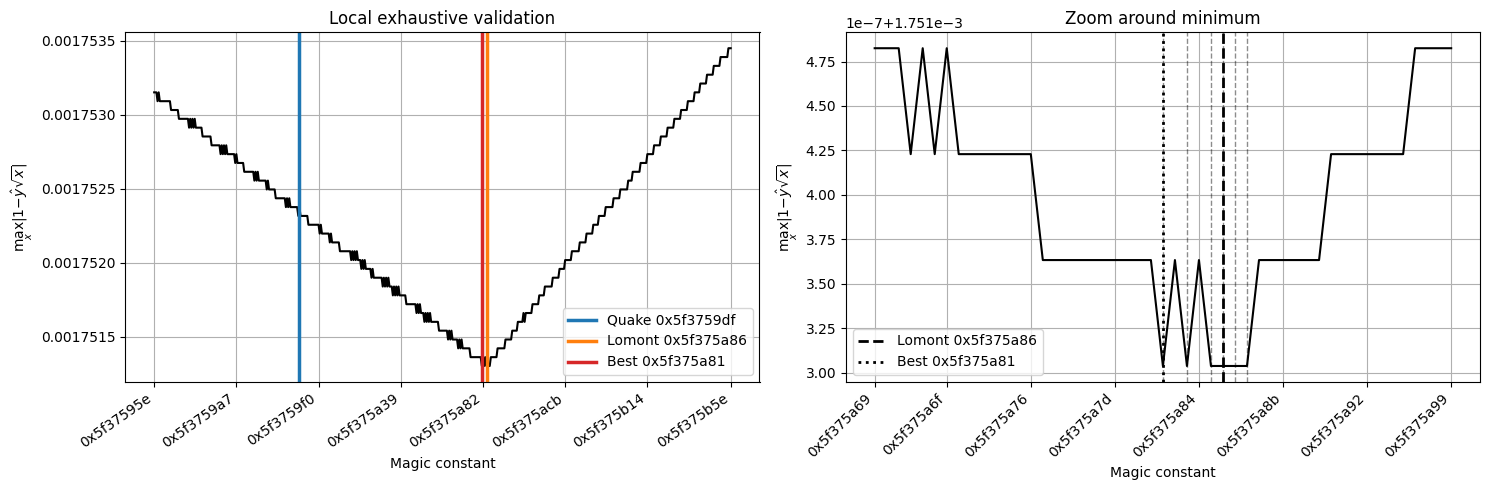

In [29]:
import numpy as np
import matplotlib.pyplot as plt


def qrsqrt(x, C):
    x = x.astype(np.float32, copy=False)
    y = (np.uint32(C) - (x.view(np.uint32) >> np.uint32(1))).view(np.float32)
    return np.float32(y * (np.float32(1.5) - np.float32(0.5) * x * y * y))


def maxerr_lomont(C, a, b, bit_step=1, chunk=1_000_000):
    max_err = 0.0
    for s in range(a, b, chunk * bit_step):
        bits = np.arange(s, min(s + chunk * bit_step, b), bit_step, dtype=np.uint32)
        x = bits.view(np.float32)
        err = np.abs(np.float32(1.0) - qrsqrt(x, C) * np.sqrt(x, dtype=np.float32))
        max_err = max(max_err, float(err.max()))
    return max_err


def ternary_int(lo, hi, f):
    cache = {}

    def F(c):
        cache.setdefault(c, f(c))
        return cache[c]

    while hi - lo > 16:
        m1, m2 = lo + (hi - lo) // 3, hi - (hi - lo) // 3
        lo, hi = (lo, m2 - 1) if F(m1) < F(m2) else (m1 + 1, hi)

    return min(((c, F(c)) for c in range(lo, hi + 1)), key=lambda t: t[1])


def group_by_error(constants, errors, decimals=18):
    groups = {}
    for C, E in zip(constants.astype(np.uint32), errors.astype(np.float64)):
        groups.setdefault(round(float(E), decimals), []).append(int(C))
    return groups


def hex_ticks(axis, values, n=8, rot=35):
    ticks = np.linspace(values[0], values[-1], n, dtype=np.uint32)
    axis.set_xticks(ticks.astype(np.int64))
    axis.set_xticklabels([hex(int(t)) for t in ticks], rotation=rot, ha="right")


quake, lomont = 0x5F3759DF, 0x5F375A86
bit_start, bit_stop = 0x3F800000, 0x40800000

fast_C, fast_E = ternary_int(
    quake - 50_000,
    quake + 50_000,
    lambda C: maxerr_lomont(C, bit_start, bit_stop, bit_step=4096),
)
print("fast:", hex(fast_C), fast_C, f"{fast_E:.18e}")

span = 256
Cs = np.arange(fast_C - span, fast_C + span + 1, dtype=np.uint32)
Es = np.array([maxerr_lomont(int(C), bit_start, bit_stop) for C in Cs])

best_i = int(np.argmin(Es))
best_C, best_E = int(Cs[best_i]), float(Es[best_i])
quake_E = maxerr_lomont(quake, bit_start, bit_stop)
lomont_E = maxerr_lomont(lomont, bit_start, bit_stop)

groups = group_by_error(Cs, Es)

print("\nGroups by error score, first 12 sorted:")
for E in sorted(groups)[:12]:
    g = groups[E]
    print(f"E={E:.18e} | n={len(g):3d} | from={hex(g[0])} to={hex(g[-1])}")

min_constants_exact = Cs[Es == best_E].astype(np.uint32)
tol = 1e-8
near_min = Cs[Es <= best_E + tol].astype(np.uint32)

print("\nMinimum error:")
print(f"E_min = {best_E:.18e}")

print("\nConstants reaching exact minimum:")
for C in min_constants_exact:
    print(hex(int(C)), int(C))

print(f"\nConstants within {tol:.1e} of the minimum:")
print("count =", len(near_min))
print("from  =", hex(int(near_min[0])), int(near_min[0]))
print("to    =", hex(int(near_min[-1])), int(near_min[-1]))

for C in near_min:
    i = int(np.where(Cs == C)[0][0])
    print(hex(int(C)), int(C), f"{Es[i]:.18e}")

print("\n" + "=" * 70)
print("RESULTS")
print("=" * 70)

for name, C, E in (
    ("Quake", quake, quake_E),
    ("Lomont", lomont, lomont_E),
    ("Best", best_C, best_E),
):
    print(f"\n{name}:")
    print(hex(C), C, f"{E:.18e}")

print("\nDifferences:")
print("best_C - quake  =", best_C - quake)
print("best_C - lomont =", best_C - lomont)

print("\nError improvements:")
print("quake_E  - best_E =", quake_E - best_E)
print("lomont_E - best_E =", lomont_E - best_E)


zoom_pad = 24
z0, z1 = max(0, best_i - zoom_pad), min(len(Cs), best_i + zoom_pad + 1)
ZC, ZE = Cs[z0:z1], Es[z0:z1]

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(Cs.astype(np.int64), Es, color="black", lw=1.5)
for C, name, color in (
    (quake, "Quake", "tab:blue"),
    (lomont, "Lomont", "tab:orange"),
    (best_C, "Best", "tab:red"),
):
    ax[0].axvline(C, color=color, lw=2.5, label=f"{name} {hex(C)}")

ax[1].plot(ZC.astype(np.int64), ZE, color="black", lw=1.5)
for C, name, style in ((lomont, "Lomont", "--"), (best_C, "Best", ":")):
    ax[1].axvline(C, color="black", ls=style, lw=2, label=f"{name} {hex(C)}")

for C in near_min:
    if int(ZC[0]) <= int(C) <= int(ZC[-1]):
        ax[1].axvline(int(C), color="black", ls="--", lw=1, alpha=0.45)

for axis, values, title, rot in (
    (ax[0], Cs, "Local exhaustive validation", 35),
    (ax[1], ZC, "Zoom around minimum", 45),
):
    hex_ticks(axis, values, rot=rot)
    axis.set(
        xlabel="Magic constant",
        ylabel=r"$\max_x |1 - \hat y\sqrt{x}|$",
        title=title,
    )
    axis.grid(True)
    axis.legend()

plt.tight_layout()
plt.show()

The error landscape around the Quake III magic constant reveals several important observations.

First, the error landscape exhibits a clear basin around the optimum. Since this is a discrete float32 experiment, the curve should not be interpreted as smooth or strongly convex in a rigorous mathematical sense. What matters is that the famous bit hack is not based on a completely arbitrary hexadecimal value, but rather on a carefully tuned numerical approximation.

Second, the original Quake constant:

$$
\texttt{0x5f3759df}
$$

is located quite close to the experimentally observed optimums in this sampled experiment and in the scanned interval, which is what Lomont found :

$$
\texttt{0x5f375a81} \to \texttt{0x5f375a88}
$$

The difference between the two constants is only $162 \to 169$ which represents a negligible perturbation compared to the magnitude of the constant itself. Most importantly, the corresponding approximation errors differ by less than:

$$
10^{-6}
$$

after one Newton refinement step. In practice, such a difference is entirely insignificant for real-time 3D rendering applications.

This experiment is consistent with the idea that the Quake constant was obtained through empirical tuning near the theoretical logarithmic approximation:

$$
\texttt{0x5f400000}
$$

followed by local numerical adjustments intended to minimize the inverse square root approximation error.

Finally, the graph highlights a remarkable property of the Quake III trick: despite relying on an apparently mysterious hexadecimal constant, the empirical value chosen for the initialization is extremely close to the best value found in this local scan, but it should not be presented as a proven global optimum over all positive float32 inputs.